<a href="https://colab.research.google.com/github/njokinjuguna/ml-learning-labs/blob/main/Data_augmentation_to_address_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,datasets,models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix

import pathlib
from pathlib import Path
import PIL
import cv2

In [2]:
import tensorflow as tf

#load image dataset from google to our local folder called datasets
dataset_url="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)
data_dir = Path(data_dir)


In [3]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print("Dataset location:", data_dir)

image_count = len([
    f for f in data_dir.rglob("*")
    if f.suffix.lower() in [".jpg", ".jpeg"]
])

print(image_count)

Dataset location: /root/.keras/datasets/flower_photos/flower_photos
3670


In [4]:
print(data_dir)
print(data_dir.exists())
list(data_dir.iterdir())

/root/.keras/datasets/flower_photos/flower_photos
True


[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/sunflowers'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/LICENSE.txt'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/tulips'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/dandelion')]

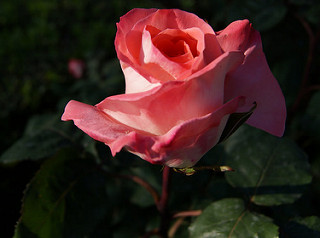

In [5]:
#lets use pillow library PIL,it helps show images.yani it enables us to do a quick visualization of the images
roses_dir = data_dir / 'roses'
roses_images = list(roses_dir.glob('*.jpg'))
PIL.Image.open(str(roses_images[1]))

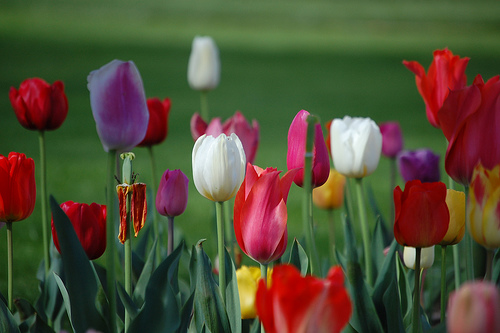

In [6]:
tulips_dir=data_dir / 'tulips'
tulips_images=list(tulips_dir.glob('*.jpg'))
PIL.Image.open(str(tulips_images[16]))


In [7]:
#lets create a dictorary  classnames for our image paths so that it will be easy for us to build our model

flower_images_dict={
    'roses':list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'tulips':list(data_dir.glob('tulips/*')),

}

In [8]:
flower_images_dict['daisy']

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/2828733818_1c1ed0089d_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/721595842_bacd80a6ac.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/14564545365_1f1d267bf1_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/5809489674_5659b3ae5d_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/5944315415_2be8abeb2f_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/11023214096_b5b39fab08.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/3704305945_a80e60e2f6_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/14716799982_ed6d626a66.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/15207766_fc2f1d692c_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/daisy/2581171297_b0a249b92b_n.jpg'),
 PosixPath('/roo

In [9]:
#also its good we create labels dictorary

flowers_labels_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [10]:
flower_images_dict['roses'][0]

PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/326541992_d542103ca8_n.jpg')

array([[[14, 15, 13],
        [15, 11, 10],
        [19, 17, 17],
        ...,
        [15,  2,  4],
        [13,  2,  4],
        [ 3,  5,  5]],

       [[34, 30, 29],
        [ 1, 10,  7],
        [ 0,  9,  7],
        ...,
        [ 0,  5,  3],
        [ 0,  7,  5],
        [ 4,  2,  2]],

       [[10, 21, 18],
        [14, 12, 11],
        [11,  9,  9],
        ...,
        [17, 11, 12],
        [11,  2,  5],
        [ 5,  0,  1]],

       ...,

       [[ 0, 11, 11],
        [20, 11, 14],
        [ 2, 14, 16],
        ...,
        [ 4,  2,  2],
        [ 6,  4,  4],
        [ 6,  4,  4]],

       [[ 0,  7,  5],
        [ 8, 10, 10],
        [ 0,  7,  7],
        ...,
        [ 3,  1,  1],
        [ 5,  3,  3],
        [ 6,  4,  4]],

       [[22,  8,  9],
        [ 0,  5,  2],
        [ 9, 10,  8],
        ...,
        [ 4,  2,  2],
        [ 4,  2,  2],
        [ 3,  1,  1]]], dtype=uint8)
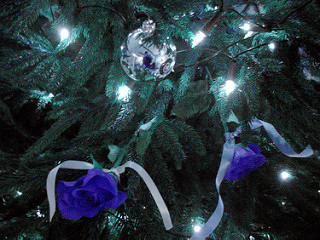

In [11]:
#lets now apply cv2 to help read image file into open cv object are numpy array
img=cv2.imread(flower_images_dict['roses'][0])
img

In [12]:
img.shape

(240, 320, 3)

In [13]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [14]:
#lets resize all our images to be same size...yani we are doing data preprpcessing
X,y=[],[]
for flower_name,images in flower_images_dict.items():
    for image in images:
        img=cv2.imread(str(image))
        resized_img=cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [15]:
X=np.array(X)
y=np.array(y)

In [16]:
#after doing our data preprocessing we can now do the split today we leave the test as default which is around 25%
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [17]:
len(X_train),len(X_test)

(2752, 918)

In [18]:
#data scaling of X_train,X_test
X_train[0],X_test[0]

(array([[[176,  65,  33],
         [176,  65,  33],
         [176,  65,  33],
         ...,
         [177,  61,  28],
         [176,  61,  28],
         [175,  61,  28]],
 
        [[179,  69,  35],
         [179,  69,  36],
         [179,  68,  36],
         ...,
         [179,  64,  31],
         [179,  64,  31],
         [178,  63,  30]],
 
        [[181,  71,  37],
         [181,  71,  37],
         [181,  70,  37],
         ...,
         [177,  64,  31],
         [177,  64,  31],
         [178,  63,  30]],
 
        ...,
 
        [[ 30,  50,  58],
         [ 76,  81, 104],
         [ 58,  82, 109],
         ...,
         [ 17, 129, 149],
         [  7, 131, 166],
         [ 12, 146, 191]],
 
        [[ 22,  43,  50],
         [ 45,  45,  62],
         [ 29,  51,  71],
         ...,
         [ 31, 145, 151],
         [ 14, 140, 159],
         [ 36, 174, 199]],
 
        [[ 20,  33,  43],
         [ 32,  20,  34],
         [ 45,  63,  77],
         ...,
         [ 81, 184, 189],
  

In [19]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255

In [20]:
X_train_scaled[0]

array([[[0.69019608, 0.25490196, 0.12941176],
        [0.69019608, 0.25490196, 0.12941176],
        [0.69019608, 0.25490196, 0.12941176],
        ...,
        [0.69411765, 0.23921569, 0.10980392],
        [0.69019608, 0.23921569, 0.10980392],
        [0.68627451, 0.23921569, 0.10980392]],

       [[0.70196078, 0.27058824, 0.1372549 ],
        [0.70196078, 0.27058824, 0.14117647],
        [0.70196078, 0.26666667, 0.14117647],
        ...,
        [0.70196078, 0.25098039, 0.12156863],
        [0.70196078, 0.25098039, 0.12156863],
        [0.69803922, 0.24705882, 0.11764706]],

       [[0.70980392, 0.27843137, 0.14509804],
        [0.70980392, 0.27843137, 0.14509804],
        [0.70980392, 0.2745098 , 0.14509804],
        ...,
        [0.69411765, 0.25098039, 0.12156863],
        [0.69411765, 0.25098039, 0.12156863],
        [0.69803922, 0.24705882, 0.11764706]],

       ...,

       [[0.11764706, 0.19607843, 0.22745098],
        [0.29803922, 0.31764706, 0.40784314],
        [0.22745098, 0

In [21]:
#model construction
model=keras.Sequential([
    #cnn
    keras.layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu',input_shape=(180,180,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(),

    #dense
    #here we first flatten the 2D(conv2D) array to 1D
    keras.layers.Flatten(),
    keras.layers.Dense(200,activation='relu'),
    keras.layers.Dense(150,activation='relu'),
    keras.layers.Dense(5,activation='softmax')]
)
#Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
#model fitting
history_original = model.fit(X_train_scaled,y_train,epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4927 - loss: 1.2203
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6363 - loss: 0.9222
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7246 - loss: 0.7229
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8216 - loss: 0.4833
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9059 - loss: 0.2701
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9520 - loss: 0.1329
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9669 - loss: 0.0960
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9720 - loss: 0.0835
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9906 - loss: 0.0362
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9906 - loss: 0.0294


In [23]:
#model evaluation
loss_original, accuracy_original = model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6024 - loss: 2.2368


In [24]:
#very good example of model overfitting,because in training the model performed very well but in testing it did so bad...

In [25]:
#model prediction
y_pred=model.predict(X_test_scaled)
y_pred=np.argmax(y_pred,axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [26]:
#classification report
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.56      0.36      0.44       176
           1       0.51      0.72      0.60       154
           2       0.83      0.60      0.69       226
           3       0.74      0.69      0.71       150
           4       0.49      0.67      0.57       212

    accuracy                           0.60       918
   macro avg       0.63      0.61      0.60       918
weighted avg       0.63      0.60      0.60       918



Text(0.5, 80.7222222222222, 'Predicted')

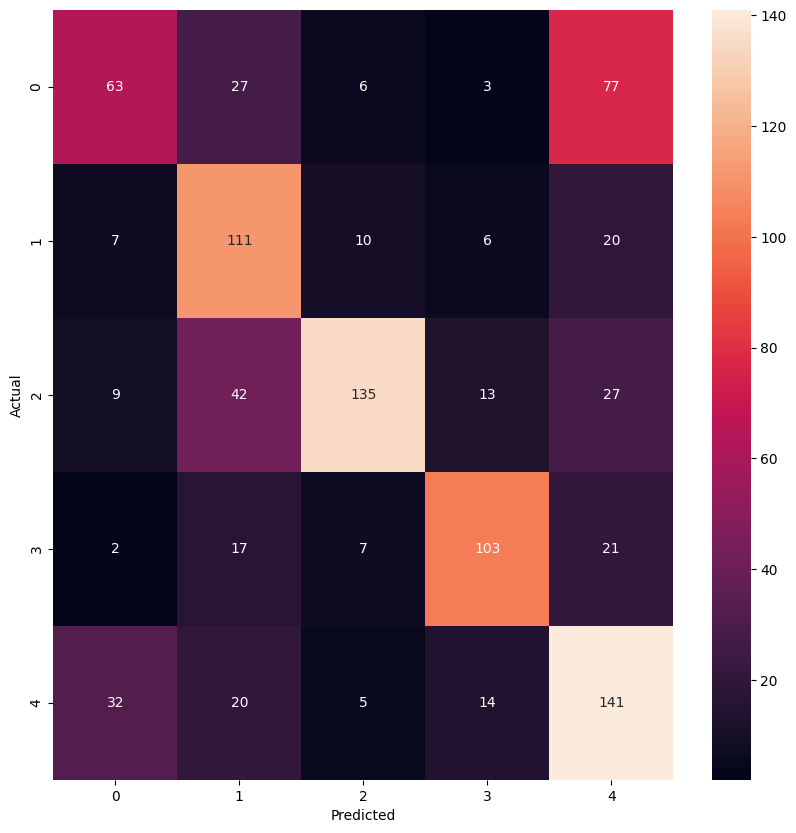

In [27]:
#confusion metrix
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Data Augmentation

## To tackle this overfitting issue in our model we will apply data augmentation

In [28]:
data_augmentation=keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomFlip("horizontal_and_vertical",input_shape=(180,180,3)),
    layers.RandomZoom(0.5),

    ])

In [29]:
#rebuild our previous model again but with a new layer of data augmentation at the top and a dropout layer

#model construction
model=keras.Sequential([
    #cnn
    data_augmentation,
    keras.layers.Conv2D(filters=16,kernel_size=(3,3),activation='relu',input_shape=(180,180,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(),
    layers.Dropout(0.2),

    #dense
    #here we first flatten the 2D(conv2D) array to 1D
    keras.layers.Flatten(),
    keras.layers.Dense(200,activation='relu'),
    keras.layers.Dense(150,activation='relu'),
    keras.layers.Dense(5,activation='softmax')]
)
#Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_augmented = model.fit(X_train_scaled,y_train,epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.4684 - loss: 1.2462
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5643 - loss: 1.0803
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6294 - loss: 0.9572
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6403 - loss: 0.9072
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6610 - loss: 0.8712
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6900 - loss: 0.8099
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6911 - loss: 0.8007
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.7024 - loss: 0.7834
Epoch 9/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7031 - loss: 0.7853
Epoch 10/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7177 - loss: 0.7543


In [30]:
#evaluation
loss_augmented, accuracy_augmented = model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6874 - loss: 0.7624


In [31]:
#predict
y_pred_data_augment=model.predict(X_test_scaled)
y_pred_data_augment=np.argmax(y_pred_data_augment,axis=1)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [32]:
#classification report
cr_data_augment=classification_report(y_test,y_pred_data_augment)
print(cr_data_augment)

              precision    recall  f1-score   support

           0       0.69      0.52      0.59       176
           1       0.59      0.77      0.67       154
           2       0.84      0.66      0.74       226
           3       0.75      0.84      0.79       150
           4       0.61      0.68      0.64       212

    accuracy                           0.69       918
   macro avg       0.70      0.70      0.69       918
weighted avg       0.70      0.69      0.69       918



Text(0.5, 80.7222222222222, 'Predicted')

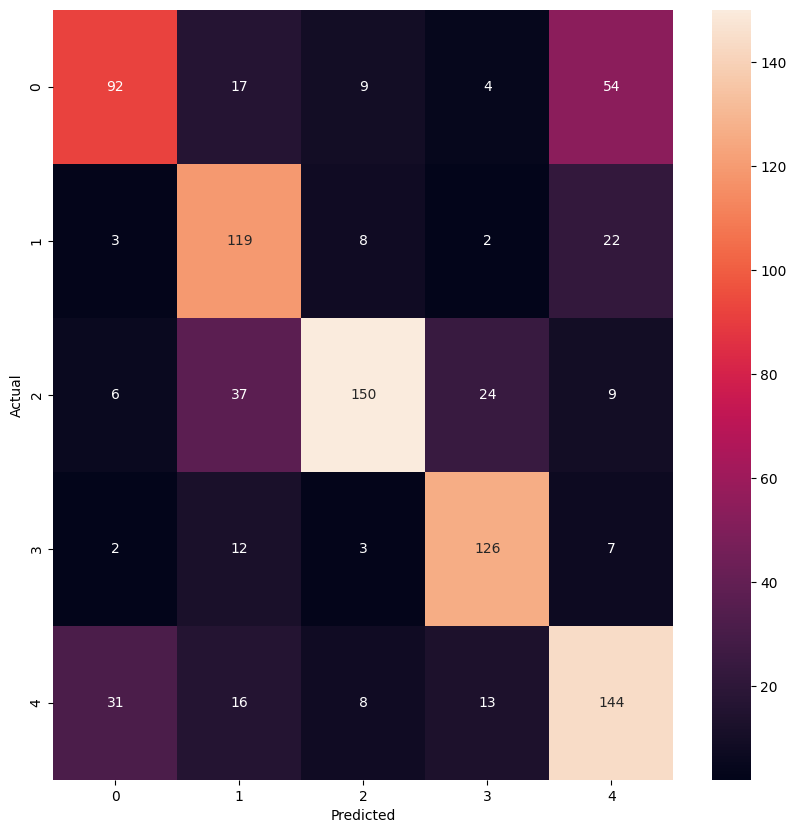

In [33]:
#confussion matrix
cm_data_augment=confusion_matrix(y_test,y_pred_data_augment)
plt.figure(figsize=(10,10))
sns.heatmap(cm_data_augment,annot=True,fmt='d')
plt.ylabel('Actual')
plt.xlabel('Predicted')

Text(0.5, 1.0, 'Loss Comparison')

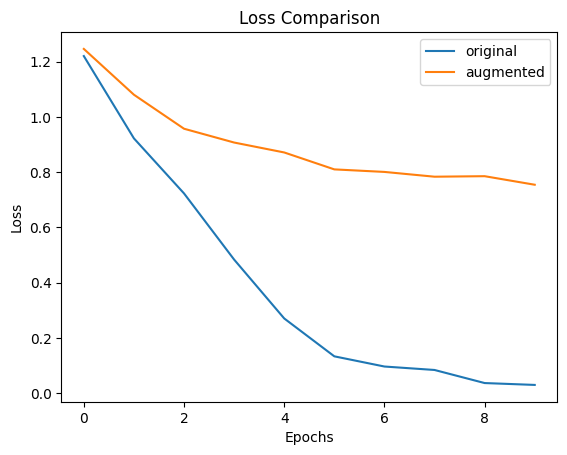

In [34]:
#lets do a comparison using histogram when overfitting and after applying data augmentation and dropout layer
#lets compare epochs and losses
plt.plot(history_original.history['loss'],label='original')
plt.plot(history_augmented.history['loss'],label='augmented')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Comparison')


Text(0.5, 1.0, 'Accuracy Comparison')

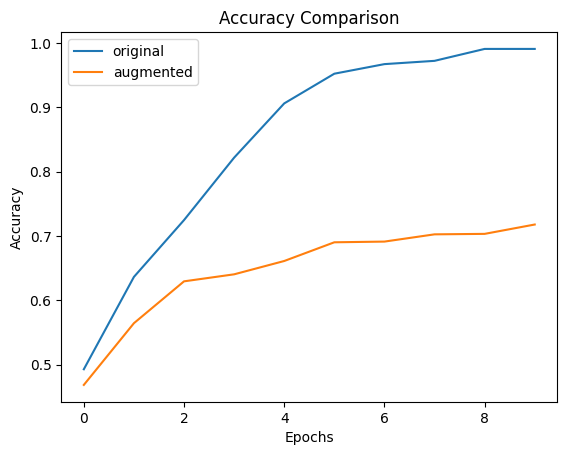

In [35]:
#lets compare the evaluation
plt.plot(history_original.history['accuracy'],label='original')
plt.plot(history_augmented.history['accuracy'],label='augmented')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')

clearly even after doing data augementation and dropout our model is still not performing so well...however vivian i hope you have understood how we apply data augementation and dropout layers..

probably for this usecase we need to handle bias-variance by either trying with an esemble model or applying the variance techniques.....